<a href="https://colab.research.google.com/github/sudipta-on/Qiskit_v2_HandsOn/blob/main/Lesson_2_DJ_Algorithm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


<div style="font-family:'Times New Roman', Times, serif; padding:20px; border-radius:14px;
background: linear-gradient(135deg,#f5f7ff,#e8f0ff); border:2px solid #d0dbff; box-shadow:0px 4px 12px rgba(0,0,0,0.08);">

<h1 style="font-size:40px; text-align:center; font-weight:bold; color:#b30000; margin-bottom:6px;">
    🚀 Quantum Fundamental Algorithms
</h1>

<h2 style="font-size:26px; text-align:center; font-weight:bold; color:#1F618D; margin-top:20px;">
    📖 Lesson 2: The Deutsch–Jozsa Algorithm
</h2>

<p style="font-size:18px; text-align:center; color:#333; margin-top:6px;">
    Exploring Quantum Speedup using <b>Qiskit SDK (v2.0+)</b>
</p>

<hr style="border:1px solid #c9d6ff; margin:14px 0;">

<p style="font-size:18px; color:#0a3d91; text-align:left;">
    📘 <b>Course:</b> Atomic Molecular and Quantum Information (AMQI)
</p>

<p style="font-size:16px; color:#444; text-align:right;">
    ⚡ Understanding quantum parallelism and interference
</p>

</div>


<h2 style="color:#7D3C98; font-weight:bold; font-size:24px; font-family:'Times New Roman', serif;">
    📑 Table of Contents
</h2>

<div style="font-family:'Times New Roman', serif; font-size:16px;font-weight:bold; line-height:2;">

<ul style="list-style-type:none; padding-left:0;">
    <li>
        📘 <a href="#chapter0" style="text-decoration:none; color:#1F618D;">
        Chapter 0: Setup & Installation
        </a>
    </li>
    <li>
        🧠 <a href="#chapter1" style="text-decoration:none; color:#196F3D;">
        Chapter 1: Deutsch Algorithm
        </a>
    </li>
    <li>
        🚀 <a href="#chapter2" style="text-decoration:none; color:#7D6608;">
        Chapter 2: Deutsch–Jozsa Algorithm
        </a>
    </li>

</ul>

</div>

<a id="chapter0"></a>
<h2 id="chapter0" style="color:#1F618D; font-weight:bold; font-size:26px; font-family:'Times New Roman', serif; border-bottom:2px solid #5DADE2; padding-bottom:6px;">
    📘 Chapter 0: Setup & Installation
</h2>


<h2 style="color:blue; font-weight:bold; font-size:20px; font-family:'Times New Roman', serif; border-left:6px solid blue; padding-left:10px;">
    ⚙️ Installation & Environment Setup
</h2>

<p style="font-family:'Times New Roman', serif; font-size:16px; line-height:1.7;">
    For this module, you must have a working Python environment with the following packages installed:
</p>

<ul style="font-family:'Times New Roman', serif; font-size:15px; line-height:1.8;">
    <li><code>qiskit</code> ≥ 2.1.0</li>
    <li><code>qiskit-aer</code> ≥ 0.17.0</li>
    <li><code>qiskit-ibm-runtime</code> ≥ 0.40.1</li>
    <li><code>numpy</code>, <code>pylatexenc</code>, <code>matplotlib</code></li>
</ul>
<p style="font-family:'Times New Roman', serif; font-size:16px; line-height:1.7;">
    To set up and install the packages above, see the <a href="https://quantum.cloud.ibm.com/docs/en/guides/install-qiskit">Install Qiskit</a> guide.
</p>


<details style="margin-top:10px;">
    <summary style="color:#8E44AD; font-weight:bold; font-family:'Times New Roman', serif; font-size:17px; cursor:pointer;">
        📦 Package Overview
    </summary>
<br>

<ul style="font-family:'Times New Roman', serif; font-size:16px; line-height:1.8;">
    <li><b>qiskit</b> → Core SDK for constructing and executing quantum circuits</li>
    <li><b>qiskit-aer</b> → High-performance simulators (statevector, noisy simulation)</li>
    <li><b>qiskit-ibm-runtime</b> → Run circuits on IBM Quantum hardware</li>
    <li><b>qiskit[visualization]</b> → Bloch sphere, circuit diagrams, state plots</li>
    <li><b>matplotlib</b> → Plotting and visualization</li>
    <li><b>numpy</b> → Numerical computations</li>
    <li><b>pylatexenc</b> → Required for LaTeX rendering in circuits</li>
</ul>

</details>


<p style="font-family:'Times New Roman', serif; font-size:15px; color:#7F8C8D; margin-top:12px;">
    💡 <b>Tip:</b> Restart your Jupyter kernel after installation to ensure all packages are properly loaded.
</p>
<p style="font-family:'Times New Roman', serif; font-size:16px; line-height:1.6;">
Run the below code to install required packages</p>

In [ ]:
!pip install qiskit qiskit-ibm-runtime qiskit-aer matplotlib pylatexenc yes -q

<h2 style="color:blue; font-weight:bold; font-size:20px; font-family:'Times New Roman', serif; border-left:6px solid blue; padding-left:10px;">
    📦 Import Required Libraries
</h2>
<p style="font-family:'Times New Roman', serif; font-size:16px;">
    Import the required libraries for building, simulating, and visualizing quantum circuits.
</p>


In [ ]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit_aer.noise import NoiseModel, depolarizing_error
import numpy as np
from math import pi
import matplotlib.pyplot as plt
from IPython.display import display

<a id="chapter1"></a>
<h2 id="chapter1" style="color:#196F3D; font-weight:bold; font-size:26px; font-family:'Times New Roman', serif; border-bottom:2px solid #196F3D; padding-bottom:6px;">
    📘 Chapter 1: Deutsch Algorithm

</h2>

<div style="font-family:'Times New Roman', serif; font-size:16px; line-height:1.7;">

<p >
    Deutsch’s algorithm is one of the simplest quantum algorithms that demonstrates <b>quantum advantage</b>. It solves the parity problem for the special case that $n = 1.$
    In the context of quantum computing this problem is sometimes referred to as <b>Deutsch's problem</b>, and we'll follow that nomenclature in this lesson.<br>
    To be precise, the input is represented by a function $f: {0,1} \rightarrow {0,1} $ from one bit to one bit.
    <br>
    There are four such functions:
</p>

$$
\rule[-10mm]{0mm}{10mm}
\begin{array}{c|c}
  a & f_1(a)\\
  \hline
  0 & 0\\
  1 & 0
\end{array}
\qquad
\begin{array}{c|c}
  a & f_2(a)\\
  \hline
  0 & 0\\
  1 & 1
\end{array}
\qquad
\begin{array}{c|c}
  a & f_3(a)\\
  \hline
  0 & 1\\
  1 & 0
\end{array}
\qquad
\begin{array}{c|c}
  a & f_4(a)\\
  \hline
  0 & 1\\
  1 & 1
\end{array}
$$

<p>
The first and last of these functions are <b>constant</b> and the middle two are <b>balanced</b>, meaning that the two possible output values for the function occur the same number of times as we range over the inputs. i.e., <b>Constant:</b> $f(0) = f(1)$ and <b>Balanced:</b> $f(0) ≠ f(1)$<br>
Deutsch's problem is to determine which of these two categories the input function belongs to: <b>constant</b> or <b>balanced</b>.
</p>

<h2 style="color:blue; font-weight:bold; font-size:20px; font-family:'Times New Roman', serif; border-left:6px solid blue; padding-left:10px;">
    🔍 Problem Statement
</h2>

<p>
<b style="color:blue">Input</b> : a function $f:\{0,1\}\rightarrow\{0,1\}$
<b style="color:blue">Output</b> : $0$ if $f$ is constant, $1$ if $f$ is balanced
</p>

<p>
    If we view the input function $f$ in Deutsch's problem as representing random access to a string, we're thinking about a two-bit string: $f(0)f(1).$
</p>

$$
\begin{array}{cc}
\mathsf{function} & \mathsf{string}\\
\hline
f_1 & 00 \\
f_2 & 01 \\
f_3 & 10 \\
f_4 & 11
\end{array}
$$
<p>
    When viewed in this way, Deutsch's problem is to compute the parity (or, equivalently, the exclusive-OR) of the two bits.
</p>


<h3 style="color:#117A65; font-family:'Times New Roman', serif;">
    ⚡ Classical vs Quantum
</h3>
Every classical query algorithm that correctly solves this problem must query both bits: $f(0)$ and $f(1).$
If we learn that $f(1) = 1,$ for instance, the answer could still be $0$ or $1,$ depending on whether $f(0) = 1$ or $f(0) = 0,$ respectively.
Every other case is similar; knowing just one of two bits doesn't provide any information at all about their parity.
So, the Boolean circuit described in the previous section is the best we can do in terms of the number of queries required to solve this problem.

<ul>
    <li>Classical → requires <b>2 queries</b></li>
    <li>Quantum → requires <b>1 query</b></li>
</ul>

<p >
    💡 This demonstrates a fundamental quantum speedup.
</p>

<h2 style="color:blue; font-weight:bold; font-size:20px; font-family:'Times New Roman', serif; border-left:6px solid blue; padding-left:10px;">
    📊 Quantum Circuit
</h2>

<p>Here is a quantum circuit that describes Deutsch's algorithm:</p>
<div style="text-align:center; margin:15px 0;">
    <img src="https://quantum.cloud.ibm.com/learning/images/courses/fundamentals-of-quantum-algorithms/quantum-query-algorithms/Deutsch-circuit.svg"
    width="70%" style="border-radius:8px; box-shadow:0px 3px 8px rgba(0,0,0,0.1);">
    <p style="font-family:'Times New Roman', serif; font-size:15px; color:#566573; margin-top:8px; text-align:center">
        Figure: Deutsch's Algorithm
    </p>

</div>

<details style="font-family:'Times New Roman', serif; font-size:16px;">
<summary style="color:blue; font-weight:bold; font-size:20px; font-family:'Times New Roman', serif; border-left:6px solid blue; padding-left:10px;">
    🔍 Analysis
</summary>

<p style="font-family:'Times New Roman', serif; font-size:16px; line-height:1.7;">
    We analyze Deutsch’s algorithm by tracking how the quantum state evolves through the circuit.
</p>
<div style="text-align:center; margin:15px 0;">
    <img src="https://quantum.cloud.ibm.com/learning/images/courses/fundamentals-of-quantum-algorithms/quantum-query-algorithms/Deutsch-circuit-states.svg"
    width="70%" style="border-radius:8px; box-shadow:0px 3px 8px rgba(0,0,0,0.1);">
    <p style="font-family:'Times New Roman', serif; font-size:15px; color:#566573; margin-top:8px; text-align:center">
        Figure: States during Deutsch's algorithm
    </p>
</div>

<h4 style="color:#1F618D; font-family:'Times New Roman', serif;">
    ⚛️ Initial State
</h4>

$$
\vert \pi_1 \rangle = \vert - \rangle \vert + \rangle
= \frac{1}{2} \bigl( \vert 0\rangle - \vert 1\rangle \bigr) \vert 0\rangle
+ \frac{1}{2} \bigl( \vert 0\rangle - \vert 1\rangle \bigr) \vert 1\rangle.
$$
<h4 style="color:#1F618D; font-family:'Times New Roman', serif;">
    ⚡ After Oracle $U_f$
</h4>

According to the definition of the $U_f$ gate, $|b\rangle|a\rangle \rightarrow |b \oplus f(a)\rangle |a\rangle$
which transforms $\vert \pi_1\rangle$ into the state

$$
\vert \pi_2 \rangle
= \frac{1}{2} \bigl( \vert 0 \oplus f(0) \rangle - \vert 1 \oplus f(0) \rangle \bigr) \vert 0 \rangle
+ \frac{1}{2} \bigl( \vert 0 \oplus f(1) \rangle - \vert 1 \oplus f(1) \rangle \bigr) \vert 1 \rangle.
$$

<p style="font-family:'Times New Roman', serif; font-size:16px; line-height:1.7;">
    Due to the special state $|-\rangle$, the function value is encoded as a phase:
</p>

<p style="text-align:center; font-size:17px;">
    $$|-\rangle |a\rangle \xrightarrow{U_f} (-1)^{f(a)} |-\rangle |a\rangle$$
</p>

<div style="font-family:'Times New Roman', serif; margin:10px 0; padding:8px 12px; background:#FEF5E7; border-left:4px solid #F8C471; font-size:15px;">

<h4 style="color:#1F618D; font-family:'Times New Roman', serif;">
    💡 Phase Kickback
</h4>

<p style="font-family:'Times New Roman', serif; font-size:16px; line-height:1.7;">
    The function values do not appear as classical bits but as <b>phases</b>:
</p>

<p style="text-align:center; font-size:17px;">
    $$(-1)^{f(0)}, \quad (-1)^{f(1)}$$
</p>

<p style="font-family:'Times New Roman', serif; font-size:15px;">
    This transfer of information via phase is called <b>phase kickback</b>.
</p>
</div>

<h4 style="color:#1F618D; font-family:'Times New Roman', serif;">
    🔄 Final Interference
</h4>

$$
\begin{aligned}
  \vert\pi_2\rangle
  & = \frac{1}{2} (-1)^{f(0)} \vert - \rangle \vert 0 \rangle
  + \frac{1}{2} (-1)^{f(1)} \vert - \rangle \vert 1 \rangle = \vert - \rangle \biggl( \frac{(-1)^{f(0)} \vert 0\rangle + (-1)^{f(1)} \vert 1\rangle}{\sqrt{2}}\biggr)\\
  & = (-1)^{f(0)} \vert - \rangle
      \biggl( \frac{\vert 0\rangle + (-1)^{f(0) \oplus f(1)} \vert 1\rangle}{\sqrt{2}}\biggr) \\
  & = \begin{cases}
        (-1)^{f(0)} \vert - \rangle \vert + \rangle & \text{if $f(0) \oplus f(1) = 0$}\\[1mm]
        (-1)^{f(0)} \vert - \rangle \vert - \rangle & \text{if $f(0) \oplus f(1) = 1$}.
      \end{cases}
\end{aligned}
$$

<p style="text-align:center; font-size:17px;">
    $$|\psi\rangle = |-\rangle \frac{|0\rangle + (-1)^{f(0)\oplus f(1)} |1\rangle}{\sqrt{2}}$$
</p>

<p style="font-family:'Times New Roman', serif; font-size:16px;">
    After applying the final Hadamard:
</p>

$$
\vert \pi_3 \rangle =
\begin{cases}
  (-1)^{f(0)} \vert - \rangle \vert 0 \rangle & \text{if $f(0) \oplus f(1) = 0$}\\[1mm]
  (-1)^{f(0)} \vert - \rangle \vert 1 \rangle & \text{if $f(0) \oplus f(1) = 1$},
\end{cases}
$$
<p>
   which leads to the correct outcome with probability $1$ when the right/topmost qubit is measured.    
</p>

</details>


<h3 style="color:blue; font-family:'Times New Roman', serif; font-weight:bold">
    🔍 Qiskit Implementation
</h3>

<h4 style="color:green; font-family:'Times New Roman', serif; font-size:18px; font-weight:bold;">
Define the Oracle
</h4>

In [ ]:
def oracle_d(case: int):
    # This function generates a quantum circuit for one of the 4 functions
    # from one bit to one bit

    if case not in [1, 2, 3, 4]:
        raise ValueError("`case` must be 1, 2, 3, or 4.")

    f = QuantumCircuit(2)
    if case in [2, 3]:
        f.cx(0, 1)
    if case in [3, 4]:
        f.x(1)
    return f

def function_type(case):
    return "Constant" if case in [1, 4] else "Balanced"

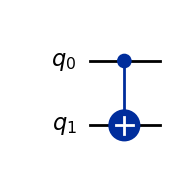

In [ ]:
oracle_d(2).draw(output="mpl")

<h4 style="color:green; font-family:'Times New Roman', serif; font-size:20px; font-weight:bold;">
Build Deutsch Circuit
</h4>

Next we will create the actual quantum circuit for Deutsch's algorithm, substituting the query gate with a quantum circuit implementation given as an argument. Shortly we'll plug in one of the four circuits defined by the function `deutsch_function` we defined earlier.
Barriers are included to show the visual separation between the query gate implementation and the rest of the circuit.



In [ ]:
def deutsch_circuit(case):
    qc = QuantumCircuit(2, 1)
    # Step 1: Prepare |0>|1>
    qc.x(1)

    # Step 2: Superposition
    qc.h([0, 1])
    qc.barrier()

    # Step 3: Apply Oracle
    qc.compose(oracle_d(case), inplace=True)
    qc.barrier()

    # Step 4: Interference
    qc.h(0)

    # Step 5: Measurement
    qc.measure(0, 0)

    return qc

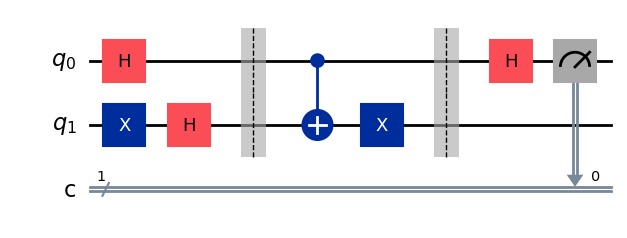

In [ ]:
qc = deutsch_circuit(3)
qc.draw("mpl")

<h4 style="color:green; font-family:'Times New Roman', serif; font-size:20px; font-weight:bold;">
Run & Display Results
</h4>

In [ ]:
def run_deutsch(case, shots=1024):
    qc = deutsch_circuit(case)

    simulator = AerSimulator()
    result = simulator.run(qc, shots=shots).result()
    counts = result.get_counts()

    print(f"\nCase {case}")
    print(f"Function Type: {function_type(case)}")

    for outcome, freq in counts.items():
        print(f"Measured {outcome} with frequency {freq}")

    display(qc.draw("mpl", fold=-1))

    return counts


Case 2
Function Type: Balanced
Measured 1 with frequency 1024


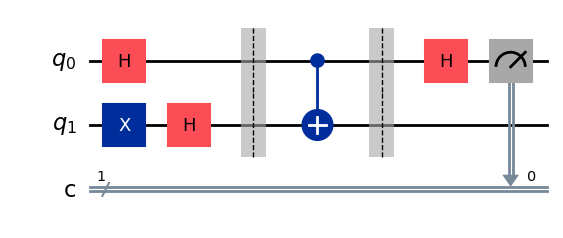

In [ ]:
c = run_deutsch(2)

<a id="chapter2"></a>
<h2 id="chapter2" style="color:#196F3D; font-weight:bold; font-size:26px; font-family:'Times New Roman', serif; border-bottom:2px solid #196F3D; padding-bottom:6px;">
    📘 Chapter 2: Deutsch-Jozsa algorithm


</h2>

<div style="font-family:'Times New Roman', serif; font-size:16px; line-height:1.7;">
    
<b>Deutsch's algorithm</b> was an important first step in demonstrating how a quantum computer might be more efficient than a classical computer, but it was only a modest improvement: it required just one query, compared to two in the classical case. In 1992, Deutsch and his colleague, Richard Jozsa, extended the original two-qubit algorithm to more qubits. The problem remained the same: determine whether a function is balanced or constant. But this time, the function goes from $n$ bits to a single bit. Either the function returns 0 and 1 an equal number of times (it's balanced) or the function returns always 1 or always 0 (it's constant).

Here's a circuit diagram of the algorithm:


<div style="text-align:center; margin:15px 0;">
    <img src="https://quantum.cloud.ibm.com/learning/images/courses/fundamentals-of-quantum-algorithms/quantum-query-algorithms/Deutsch-Jozsa.svg"
    width="70%" style="border-radius:8px; box-shadow:0px 3px 8px rgba(0,0,0,0.1);">
    <p style="font-family:'Times New Roman', serif; font-size:15px; color:#566573; margin-top:8px; text-align:center">
        Figure: Deutsch-Jozsa algorithm
    </p>
</div>

<h2 style="color:blue; font-weight:bold; font-size:20px; font-family:'Times New Roman', serif; border-left:6px solid blue; padding-left:10px;">
    🔍 Problem Statement
</h2>

<p>
<b style="color:blue">Input</b> : a function $f:\{0,1\}^n\rightarrow\{0,1\}$
<b style="color:blue">Output</b> : $0$ if $f$ is constant, $1$ if $f$ is balanced
</p>

This algorithm works in the same way as Deutsch's algorithm: the phase-kickback allows one to read out the state of qubit 0 to determine whether the function is constant or balanced. It's a bit trickier to see than for the two-qubit Deutsch's algorithm case, since the states will include sums over the $n$ qubits, and so working out those states will be left as an optional exercise for you at the end of the module. The algorithm will return a bitstring of all 0's if the function is constant, and a bitstring containing at least one 1 if the function is balanced.

</div>


<h3 style="color:blue; font-family:'Times New Roman', serif; font-weight:bold">
    🔍 Qiskit Implementation
</h3>

<h4 style="color:green; font-family:'Times New Roman', serif; font-size:18px; font-weight:bold;">
Define the Oracle
</h4>

In [ ]:
def simple_dj_oracle(n, case="balanced"):
    qc = QuantumCircuit(n + 1)

    if case == "constant":
        # f(x) = 0 or 1
        qc.x(n)

    elif case == "balanced":
        # XOR of all inputs
        for i in range(n):
            qc.cx(i, n)

    return qc

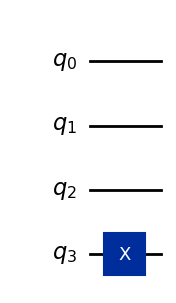

In [ ]:
oracle=simple_dj_oracle(3, "constant")
oracle.draw("mpl")

<h4 style="color:green; font-family:'Times New Roman', serif; font-size:18px; font-weight:bold;">
Build Main Circuit
</h4>

In [ ]:
def dj_circuit(oracle, n):
    """
    Constructs the Deutsch–Jozsa algorithm circuit.
    """
    # Convert oracle circuit into a reusable gate
    blackbox = oracle.to_gate()
    blackbox.label = "$U_f$"   # Label for visualization

    # Create circuit:
    # n input qubits + 1 output qubit, and n classical bits
    qc_dj = QuantumCircuit(n + 1, n)
    qc_dj.x(n)

    # Apply Hadamard to all qubits
    qc_dj.h(range(n + 1))
    qc_dj.barrier()

    # Apply Oracle U_f
    qc_dj.compose(blackbox, inplace=True)
    qc_dj.barrier()

    # Apply Hadamard to input qubits
    qc_dj.h(range(n))

    # Measure input qubits
    qc_dj.measure(range(n), range(n))

    return qc_dj

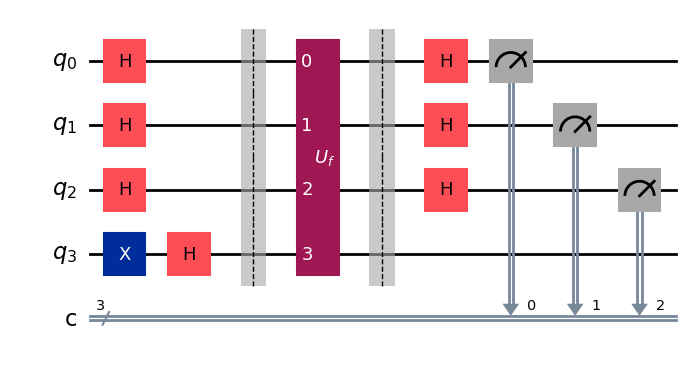

In [ ]:
n = 3
oracle = simple_dj_oracle(n, "balanced")

qc_dj = dj_circuit(oracle, n)

qc_dj.draw("mpl", fold=-1)

<h4 style="color:green; font-family:'Times New Roman', serif; font-size:18px; font-weight:bold;">
Run & Display Results
</h4>

In [ ]:
def run_dj(n=3, case="balanced", shots=1024):

    oracle = simple_dj_oracle(n, case)
    qc = dj_circuit(oracle, n)

    simulator = AerSimulator()
    result = simulator.run(transpile(qc, simulator), shots=shots).result()
    counts = result.get_counts()

    print(f"\nFunction Type: {case.upper()}")
    for outcome, freq in counts.items():
        print(f"Measured {outcome} → {freq}")

    display(qc.draw("mpl", fold=-1))

    return counts


Function Type: CONSTANT
Measured 000 → 1024


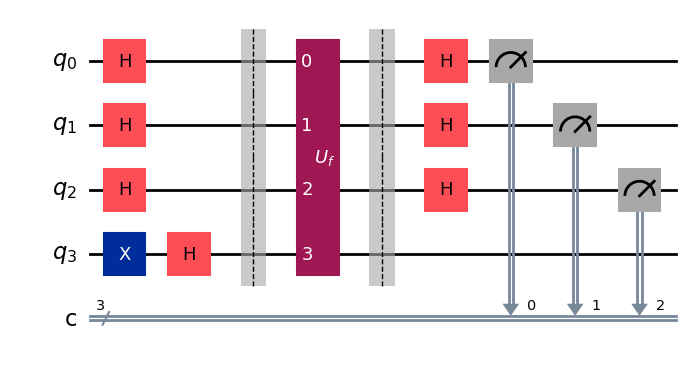

In [ ]:
cc = run_dj(n=3, case="constant")


Function Type: BALANCED
Measured 111 → 1024


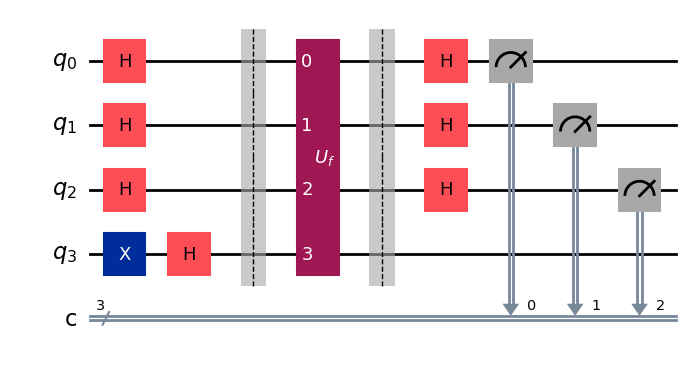

In [ ]:
bc = run_dj(n=3, case="balanced")

<h4 style="color:green; font-family:'Times New Roman', serif; font-size:18px; font-weight:bold;">
Let Explore
</h4>

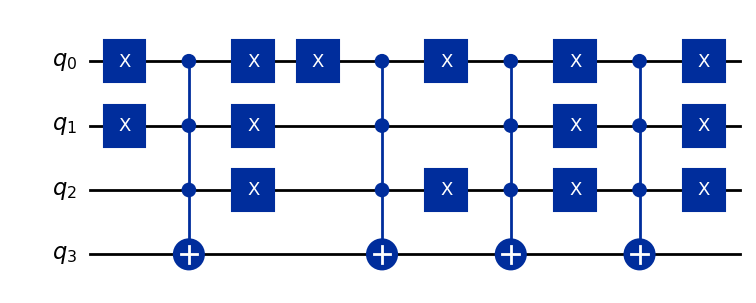

In [ ]:
def random_dj_oracle(num_qubits):
    """
    Create a random Deutsch-Jozsa function.
    """

    qc_dj = QuantumCircuit(num_qubits + 1)

    # Random flip (constant 1 vs 0)
    flip = np.random.randint(0, 2)
    if flip:
        qc_dj.x(num_qubits)

    # Decide constant or balanced
    is_constant = np.random.randint(0, 2)

    if is_constant:
        return qc_dj, "constant"

    # If the "if" statement above was "TRUE" then we've returned the constant function and the function is complete.
    # If not, we proceed in creating our balanced function. Everything below is to produce the balanced function:

    # ---------------- Balanced case ----------------

    # select half of all possible states at random:
    on_states = np.random.choice(
        range(2**num_qubits),  # numbers to sample from
        2**num_qubits // 2,  # number of samples
        replace=False,  # makes sure states are only sampled once
    )

    def add_cx(qc_dj, bit_string):
        for qubit, bit in enumerate(reversed(bit_string)):
            if bit == "1":
                qc_dj.x(qubit)
        return qc_dj

    for state in on_states:
        bit_string = format(state, f"0{num_qubits}b")
        qc_dj = add_cx(qc_dj, bit_string)
        qc_dj.mcx(list(range(num_qubits)), num_qubits)
        qc_dj = add_cx(qc_dj, bit_string)

    return qc_dj, "balanced"


n = 3  # number of input qubits

oracle, func_type = random_dj_oracle(n)

display(oracle.draw("mpl"))

In [ ]:
def run_dj_rand(n=3, shots=1024):

    oracle, true_type = random_dj_oracle(n)
    qc = dj_circuit(oracle, n)

    simulator = AerSimulator()
    result = simulator.run(transpile(qc, simulator), shots=shots).result()
    counts = result.get_counts()

    # ---------------- Interpretation ----------------
    measured_state = list(counts.keys())[0]

    if measured_state == "0" * n:
        predicted_type = "constant"
    else:
        predicted_type = "balanced"

    # ---------------- Print ----------------
    print("\n=== Deutsch–Jozsa Result ===")
    print(f"True Function Type     : {true_type.upper()}")
    print(f"Predicted Function Type: {predicted_type.upper()}")
    print("\nCounts:")

    for outcome, freq in counts.items():
        print(f"{outcome} → {freq}")

    # ---------------- Display ----------------
    display(qc.draw("mpl", fold=-1))

    return counts


=== Deutsch–Jozsa Result ===
True Function Type     : BALANCED
Predicted Function Type: BALANCED

Counts:
100 → 255
001 → 215
111 → 281
010 → 273


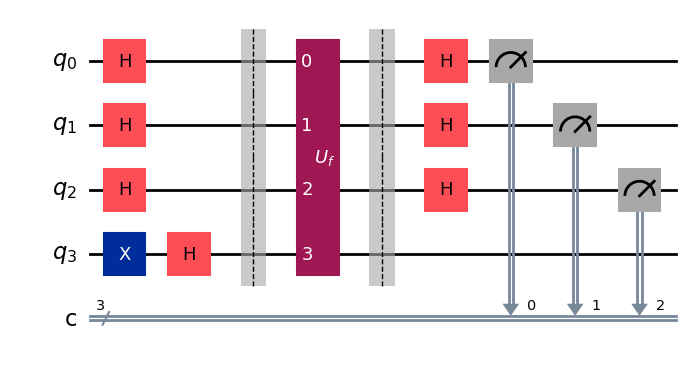

In [ ]:
counts = run_dj_rand(3)

In [ ]:
import pkg_resources
import platform

print("🔹 Installed Qiskit-related Packages\n")

for pkg in sorted(pkg_resources.working_set, key=lambda x: x.project_name.lower()):
    if "qiskit" in pkg.project_name.lower():
        print(f"{pkg.project_name} == {pkg.version}")

print("\n🔹 System Info")
print("Python:", platform.python_version())
print("OS:", platform.system(), platform.release())

🔹 Installed Qiskit-related Packages

qiskit == 2.3.0
qiskit-aer == 0.17.2
qiskit-algorithms == 0.4.0
qiskit-code-assistant-jupyterlab == 0.10.0
qiskit-ibm-runtime == 0.45.0
qiskit-nature == 0.7.2

🔹 System Info
Python: 3.11.8
OS: Darwin 24.6.0


<hr>
<p style="text-align:center; font-family:'Times New Roman', serif; font-size:13px; color:#5D6D7E;">
    ⚛️ Atomic, Molecular and Quantum Information (AMQI) Group <br>
    Department of Physics • Quantum Computing Notebook <br>
    Built using Qiskit Framework
</p>